In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load and Explore the Data

In [2]:
# Load train and test datasets
train = pd.read_csv("train.csv")
test  = pd.read_csv("test.csv")

print("Train shape:", train.shape)   # Should be (1460, 81)
print("Test shape: ", test.shape)    # Should be (1459, 80)

print("\nFirst 3 rows of train:")
print(train.head(3))

print("\nFirst 3 rows of test:")
print(test.head(3))

print("\n  Note: test.csv has NO SalePrice column — we will predict it!")

Train shape: (1460, 81)
Test shape:  (1459, 80)

First 3 rows of train:
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD         Normal     208500  
1   2007        WD         Normal     181500  
2   2008        WD         Normal     223500  

[3 rows x 81 columns]

First 3 rows of test:
     Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape

# Select Features

In [3]:
features = ["GrLivArea", "BedroomAbvGr", "FullBath"]
target   = "SalePrice"

# --- From TRAIN: get features + target ---
train_clean = train[features + [target]].dropna()
X_train_raw = train_clean[features].values   # shape (N, 3)
y_train_raw = train_clean[target].values     # shape (N,)

# --- From TEST: get features only (no SalePrice!) ---
test_clean  = test[features].fillna(test[features].median())
X_test_raw  = test_clean.values              # shape (M, 3)

print("Features selected!")
print("Train X shape:", X_train_raw.shape)
print("Train y shape:", y_train_raw.shape)
print("Test  X shape:", X_test_raw.shape)
print("\nFeature meanings:")
print("  GrLivArea    = Above-ground living area (sq ft)")
print("  BedroomAbvGr = Number of bedrooms")
print("  FullBath     = Number of full bathrooms")

Features selected!
Train X shape: (1460, 3)
Train y shape: (1460,)
Test  X shape: (1459, 3)

Feature meanings:
  GrLivArea    = Above-ground living area (sq ft)
  BedroomAbvGr = Number of bedrooms
  FullBath     = Number of full bathrooms


# Normalize Features (Scaling)

In [4]:
# Calculate mean and std FROM TRAINING DATA ONLY
X_mean = X_train_raw.mean(axis=0)
X_std  = X_train_raw.std(axis=0)

# Normalize BOTH train and test using SAME values
X_train = (X_train_raw - X_mean) / X_std
X_test  = (X_test_raw  - X_mean) / X_std   # use train's mean/std!

# Normalize target
y_mean = y_train_raw.mean()
y_std  = y_train_raw.std()
y_train = (y_train_raw - y_mean) / y_std

print("Normalization done!")
print("Mean of each feature:", X_mean)
print("Std  of each feature:", X_std)
print("Mean of SalePrice:   ", y_mean)

Normalization done!
Mean of each feature: [1515.46369863    2.86643836    1.56506849]
Std  of each feature: [525.30039356   0.81549862   0.5507271 ]
Mean of SalePrice:    180921.19589041095


# Add Bias Column

In [5]:
m_train = X_train.shape[0]
m_test  = X_test.shape[0]

# Add ones column to both train and test
ones_train = np.ones((m_train, 1))
ones_test  = np.ones((m_test,  1))

X_train_b = np.hstack((ones_train, X_train))   # shape: (1460, 4)
X_test_b  = np.hstack((ones_test,  X_test))    # shape: (1459, 4)

print("Bias column added!")
print("X_train_b shape:", X_train_b.shape)
print("X_test_b  shape:", X_test_b.shape)
print("First row of X_train_b:", X_train_b[0])

Bias column added!
X_train_b shape: (1460, 4)
X_test_b  shape: (1459, 4)
First row of X_train_b: [1.         0.37033344 0.16377912 0.78974052]


# Define Cost Function and Gradient Descent

In [6]:
# Cost Function: Mean Squared Error
def compute_cost(X, y, theta):
    m = len(y)
    predictions = X @ theta
    errors = predictions - y
    return (1 / (2 * m)) * np.sum(errors ** 2)

# Gradient Descent
def gradient_descent(X, y, theta, alpha, iterations):
    m = len(y)
    cost_history = []

    for i in range(iterations):
        predictions = X @ theta
        errors      = predictions - y
        gradient    = (1 / m) * (X.T @ errors)
        theta       = theta - alpha * gradient

        cost = compute_cost(X, y, theta)
        cost_history.append(cost)

        if i % 200 == 0:
            print(f"  Step {i:5d} | Cost: {cost:.6f}")

    return theta, cost_history

print("✅ Functions defined!")

✅ Functions defined!


# Train the Model on ALL of train.csv

In [7]:
theta_init = np.zeros(X_train_b.shape[1])  # [0, 0, 0, 0]
alpha      = 0.01     # learning rate
iterations = 1000     # training steps

print("🚀 Training started on ALL training data...")
theta, cost_history = gradient_descent(X_train_b, y_train, theta_init, alpha, iterations)

print("\n Training complete!")
print(f"   Final cost:         {cost_history[-1]:.6f}")
print(f"   Learned parameters: {theta}")

🚀 Training started on ALL training data...
  Step     0 | Cost: 0.491629
  Step   200 | Cost: 0.225169
  Step   400 | Cost: 0.211872
  Step   600 | Cost: 0.209232
  Step   800 | Cost: 0.208604

 Training complete!
   Final cost:         0.208445
   Learned parameters: [ 2.62389805e-16  7.13899232e-01 -2.80217971e-01  2.15917714e-01]


# Plot the Loss Curve

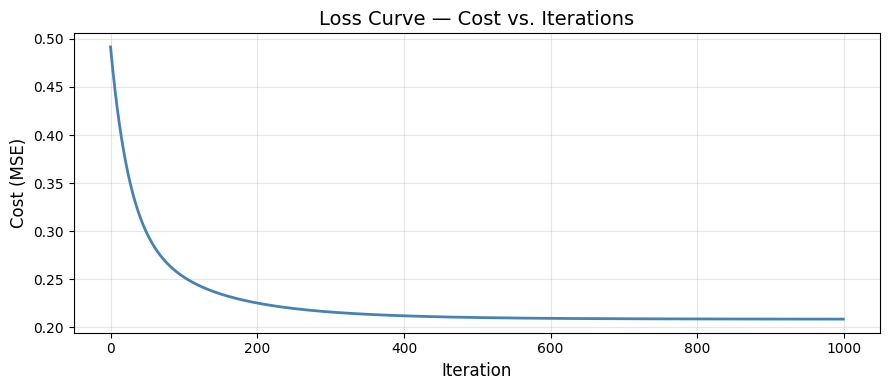

✅ Loss curve saved!


In [8]:
plt.figure(figsize=(9, 4))
plt.plot(cost_history, color='steelblue', linewidth=2)
plt.title("Loss Curve — Cost vs. Iterations", fontsize=14)
plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Cost (MSE)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150)
plt.show()
print("✅ Loss curve saved!")

# Error Metrics on Training Data

In [9]:
# Predictions on TRAINING data
y_pred_norm = X_train_b @ theta

# Convert back to dollar scale
y_pred = y_pred_norm * y_std + y_mean
y_true = y_train     * y_std + y_mean

# MAE — Mean Absolute Error
mae = np.mean(np.abs(y_pred - y_true))

# MSE — Mean Squared Error
mse = np.mean((y_pred - y_true) ** 2)

# RMSE — Root Mean Squared Error
rmse = np.sqrt(mse)

# R² — Coefficient of Determination
ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - y_mean) ** 2)
r2     = 1 - (ss_res / ss_tot)

print("=" * 45)
print("        MODEL PERFORMANCE METRICS")
print("        (measured on training data)")
print("=" * 45)
print(f"  MAE  (Mean Absolute Error):   ${mae:,.2f}")
print(f"  MSE  (Mean Squared Error):    ${mse:,.2f}")
print(f"  RMSE (Root MSE):              ${rmse:,.2f}")
print(f"  R²   (R-squared):              {r2:.4f}")
print("=" * 45)

if r2 > 0.6:
    print("Good model! R² > 0.6")
elif r2 > 0.4:
    print("Moderate model. R² between 0.4 and 0.6")
else:
    print("Model needs improvement.")

print(f"\n R² = {r2:.4f} means the model explains {r2*100:.1f}% of price variation")

        MODEL PERFORMANCE METRICS
        (measured on training data)
  MAE  (Mean Absolute Error):   $35,189.87
  MSE  (Mean Squared Error):    $2,629,241,665.59
  RMSE (Root MSE):              $51,276.13
  R²   (R-squared):              0.5831
Moderate model. R² between 0.4 and 0.6

 R² = 0.5831 means the model explains 58.3% of price variation


# Compare Actual vs Predicted (Training Data)

In [10]:
print("=" * 68)
print(f"{'#':<5} {'Actual Price':>15} {'Predicted Price':>17} {'Error':>13}")
print("=" * 68)

for i in range(10):
    actual    = y_true[i]
    predicted = y_pred[i]
    error     = abs(actual - predicted)
    print(f"{i+1:<5} ${actual:>14,.0f}   ${predicted:>14,.0f}   ${error:>11,.0f}")

print("=" * 68)
print(f"\n  Average Error (MAE): ${mae:,.0f}")

#        Actual Price   Predicted Price         Error
1     $       208,500   $       211,814   $      3,314
2     $       181,500   $       163,463   $     18,037
3     $       223,500   $       220,017   $      3,483
4     $       140,000   $       181,434   $     41,434
5     $       250,000   $       237,195   $     12,805
6     $       143,000   $       197,696   $     54,696
7     $       307,000   $       210,087   $     96,913
8     $       200,000   $       252,827   $     52,827
9     $       129,900   $       246,010   $    116,110
10    $       118,000   $       139,649   $     21,649

  Average Error (MAE): $35,190


# Actual vs Predicted Scatter Plot

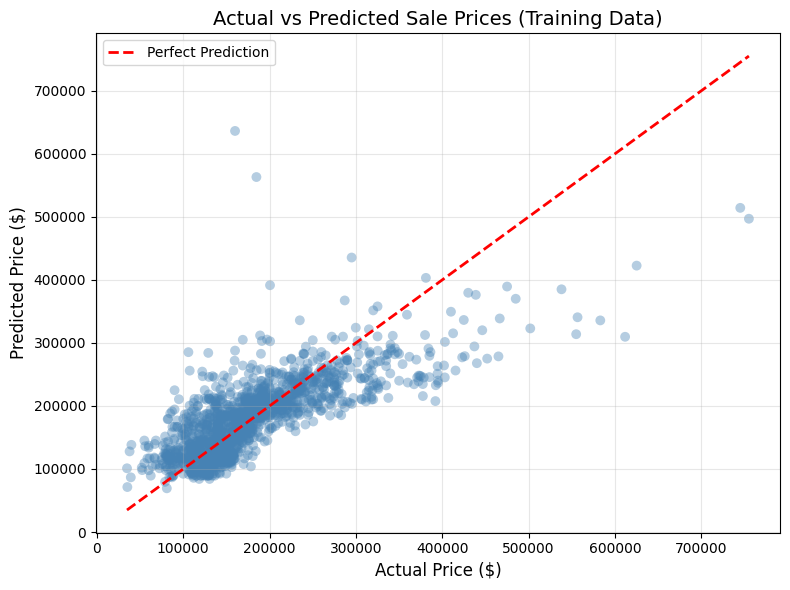

 Plot saved!


In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(y_true, y_pred, alpha=0.4, color='steelblue', edgecolors='none', s=50)

# Perfect prediction line
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val],
         'r--', linewidth=2, label='Perfect Prediction')

plt.title("Actual vs Predicted Sale Prices (Training Data)", fontsize=14)
plt.xlabel("Actual Price ($)", fontsize=12)
plt.ylabel("Predicted Price ($)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=150)
plt.show()
print(" Plot saved!")

# Predict Prices for test.csv (Final Output)

In [12]:
# Predict on TEST data
y_test_pred_norm = X_test_b @ theta
y_test_pred      = y_test_pred_norm * y_std + y_mean

# Clip negative predictions (house price can't be negative)
y_test_pred = np.maximum(y_test_pred, 0)

print(" Predictions done!")
print(f"\n Predicted prices for {len(y_test_pred)} houses:")
print(f"   Minimum predicted price:  ${y_test_pred.min():>12,.0f}")
print(f"   Maximum predicted price:  ${y_test_pred.max():>12,.0f}")
print(f"   Average predicted price:  ${y_test_pred.mean():>12,.0f}")

print("\n First 10 predictions:")
print(f"{'House #':<10} {'Predicted SalePrice':>20}")
print("-" * 32)
for i in range(10):
    print(f"{test['Id'].values[i]:<10} ${y_test_pred[i]:>18,.0f}")

 Predictions done!

 Predicted prices for 1459 houses:
   Minimum predicted price:  $      85,145
   Maximum predicted price:  $     604,438
   Average predicted price:  $     178,268

 First 10 predictions:
House #     Predicted SalePrice
--------------------------------
1461       $           120,114
1462       $           139,558
1463       $           203,072
1464       $           200,374
1465       $           192,694
1466       $           205,878
1467       $           155,368
1468       $           185,372
1469       $           168,142
1470       $           118,603


# Save Predictions to CSV File

In [13]:
# Create submission file
submission = pd.DataFrame({
    'Id':        test['Id'].values,
    'SalePrice': y_test_pred.astype(int)
})

submission.to_csv("predictions.csv", index=False)

print(" Predictions saved to predictions.csv!")
print(f"   Total predictions: {len(submission)}")
print("\nFirst 5 rows of predictions.csv:")
print(submission.head())

 Predictions saved to predictions.csv!
   Total predictions: 1459

First 5 rows of predictions.csv:
     Id  SalePrice
0  1461     120113
1  1462     139558
2  1463     203072
3  1464     200373
4  1465     192693
